# 🚗 Tunisia Used Car Market Intelligence (2025)
### *A data storytelling deep dive into affordability, turnover, and regional market dynamics*

![Python](https://img.shields.io/badge/Python-3.9%2B-3776AB?logo=python&logoColor=white) ![Pandas](https://img.shields.io/badge/Pandas-Data%20Wrangling-150458?logo=pandas&logoColor=white) ![Plotly](https://img.shields.io/badge/Plotly-Interactive%20Charts-3F4F75?logo=plotly&logoColor=white) ![Jupyter](https://img.shields.io/badge/Jupyter-Notebook-F37626?logo=jupyter&logoColor=white) ![License](https://img.shields.io/badge/License-Research%20Use-2EA44F)

**Project pitch:** This notebook transforms raw listing data into decision-ready market intelligence for pricing, inventory strategy, and economic interpretation in Tunisia's used-car market.

**Author:** Mouldi Bziou | **Data Window:** June-August 2025 | **Sources:** Tayara.tn + Automobile.tn | **Notebook Type:** Portfolio-ready analytical report

<div style="padding:14px 16px; border-radius:12px; border:1px solid #2f4f6f; background:linear-gradient(135deg, rgba(28,52,84,0.12), rgba(17,94,89,0.12));">
<b>💡 Portfolio Lens:</b> Executive storytelling + reproducible analytics + market interpretation in one notebook flow.
</div>

### 📌 TL;DR Key Findings

| Marker | Finding | Evidence Section |
|---|---|---|
| 🧭 | The market is concentrated in practical, high-liquidity segments (compact formats, petrol, manual-heavy mix). | Sections 4, 8.3 |
| 💰 | Affordability is centered around mid-range price bands, with constrained low-price inventory depth. | Section 8.2 |
| 🌍 | Clear regional divide: Greater Tunis and coastal hubs show stronger price and premium concentration than interior regions. | Section 7 |
| 🔁 | Lifecycle patterns indicate active resale cycles rather than purely long-hold ownership behavior. | Section 5 |
| 🚚 | Commercial vehicles form a distinct operational sub-market with different mileage-price behavior. | Section 6 |
| ⚡ | Hybrid/electric presence is visible but remains low-volume and generally higher priced in the observed sample. | Section 8.3 |

### ✅ What Makes This Analysis Unique?
- [x] End-to-end reproducible workflow with relative-first path fallback logic
- [x] Cross-platform listing consolidation into one coherent market narrative
- [x] Evidence-linked storytelling: every claim tied to charts/tables
- [x] Geographic + affordability + lifecycle views integrated in one framework
- [x] Business-facing implications without compromising analytical rigor

> 💼 **For Recruiters / Hiring Managers**
> This notebook demonstrates production-minded data analysis: robust data loading, clean section-level data isolation, warning-aware visualization practices, and executive-level storytelling grounded in verifiable evidence (not speculative claims).

---
## 📊 1. Executive Summary
*High-level decision view of Tunisia's used-car market structure in 2025.*

**🎯 Why this matters**  
Used-car listings offer a high-frequency lens on affordability pressure, mobility demand, and regional economic asymmetry.

**🔎 What we analyze**
- Cross-platform listing composition and dominant market segments
- Price, age, and mileage structures as turnover and affordability signals
- Regional concentration patterns and premium-market geography

**🧠 Key insight**  
The 2025 market remains practical and utility-led: mid-range affordability dominates volume, while premium concentration is region-specific.

**✅ So what?**  
Dealers, lenders, and market operators should optimize around liquid mid-range cohorts and region-differentiated pricing/inventory strategies.

---
## 🌍 2. Introduction and Market Context
*Why this market is a strategic signal beyond automotive retail.*

**🎯 Why this matters**  
Used-vehicle markets react quickly to inflation, household purchasing power shifts, and mobility constraints.

**🔎 What we analyze**
- Market structure by brand, model, body type, fuel, and engine profile
- Lifecycle indicators (registration year, age, mileage)
- Regional dispersion and affordability segmentation

**🧠 Key insight**  
Observed listing behavior reflects a market balancing necessity-driven demand with increasing affordability stress.

**✅ So what?**  
A descriptive, evidence-based market map helps stakeholders design realistic financing, stocking, and growth strategies.

---
## 🧱 3. Data Sources and Preparation
*Reproducible setup, transparent assumptions, and validation-first workflow.*

**🎯 Why this matters**  
Credible data storytelling depends on traceable sourcing, reproducible loading logic, and explicit preprocessing assumptions.

**🔎 What we analyze**
- Source platforms and collection window
- Reproducibility constraints and environment assumptions
- Baseline dataframe strategy for non-destructive analysis

**Environment / Reproducibility**
- Python 3.9+
- Libraries: pandas, numpy, seaborn, matplotlib, plotly, geopandas
- Run this notebook top-to-bottom without skipping cells
- Paths resolve with relative-first fallback candidates and explicit error reporting

**Data source note**  
The analysis uses the curated dataset produced by the project wrangling pipeline and does not inject external tabular sources inside this notebook.

> 🔍 **Key Finding:** The prepared dataset is broad enough for market-level descriptive intelligence while preserving methodological transparency.
> 📌 **Interpretation:** Reproducibility safeguards (baseline copy + fallback paths) reduce operational fragility.
> 🚀 **Implication:** The notebook can be rerun and extended as a reusable analysis asset, not a one-off experiment.

**🧠 Key insight**  
Reliable storytelling starts with reliable setup.

**✅ So what?**  
Downstream sections can focus on interpretation because data integrity and loading logic are explicitly controlled.

### 🗂️ 3.0 Dataset Profile Snapshot
*What is inside the analysis base before section-level transformations.*

| Attribute | Coverage |
|---|---|
| Observation window | June-August 2025 |
| Approximate listing count | ~4,900 |
| Core fields | price, brand, model, year, mileage, body type, fuel, transmission, engine size, fiscal power, location |
| Data role | Descriptive market intelligence (non-causal) |

> 🔍 **Key Finding:** The dataset breadth supports robust market-structure diagnostics.
> 📌 **Interpretation:** Skewed tails in price and mileage reflect real market heterogeneity.
> 🚀 **Implication:** Tail-aware summaries (medians, percentile views, segment splits) are more informative than simple averages alone.

### 🛠️ 3.1 Dataset Loading
*Load once, preserve baseline, and analyze through section-level copies.*

The following cell loads the curated dataset with robust relative-first fallback logic and creates a protected baseline dataframe (`df_base`) for non-destructive analysis.

In [3]:
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Global visualization style for consistency across sections
sns.set_theme(style="whitegrid", context="notebook")
sns.set_palette("crest")
plt.rcParams.update({
    "figure.dpi": 110,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "legend.fontsize": 10,
    "axes.titlepad": 10,
    "figure.facecolor": "white",
    "axes.facecolor": "#F8FAFC",
})


def format_count_axis(ax, axis="x"):
    formatter = mticker.StrMethodFormatter("{x:,.0f}")
    if axis in ("x", "both"):
        ax.xaxis.set_major_formatter(formatter)
    if axis in ("y", "both"):
        ax.yaxis.set_major_formatter(formatter)


def format_tnd_axis(ax, axis="y"):
    formatter = mticker.StrMethodFormatter("{x:,.0f} TND")
    if axis in ("x", "both"):
        ax.xaxis.set_major_formatter(formatter)
    if axis in ("y", "both"):
        ax.yaxis.set_major_formatter(formatter)


search_roots = [Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent]
data_candidates = []
for root in search_roots:
    data_candidates.append(root / "data_wrangling" / "final_data" / "2025_data.csv")

# Keep insertion order while removing duplicates
data_candidates = list(dict.fromkeys(data_candidates))
data_path = next((p for p in data_candidates if p.exists()), None)

if data_path is None:
    recursive_matches = []
    for root in search_roots:
        recursive_matches.extend(root.rglob("2025_data.csv"))
    recursive_matches = list(dict.fromkeys(recursive_matches))

    preferred = [
        p for p in recursive_matches
        if {"data_wrangling", "final_data"}.issubset(set(p.parts))
    ]
    data_path = preferred[0] if preferred else (recursive_matches[0] if recursive_matches else None)

if data_path is None:
    checked = "\n".join(str(p.resolve()) for p in data_candidates)
    raise FileNotFoundError(
        "Could not locate 2025_data.csv. Checked the following paths:\n"
        f"{checked}\n\nCurrent working directory: {Path.cwd()}"
    )

df = pd.read_csv(data_path)
df_base = df.copy(deep=True)

print(f"Loaded {len(df):,} rows from {data_path.resolve()}")
print("Created immutable baseline copy: df_base")

FileNotFoundError: Could not locate 2025_data.csv. Checked the following paths:
/Users/mouldi/Projects/TunisianCarsDataScience/tunisia-used-car-market-bi/Data Analysis/data_wrangling/final_data/2025_data.csv
/Users/mouldi/Projects/TunisianCarsDataScience/tunisia-used-car-market-bi/data_wrangling/final_data/2025_data.csv
/Users/mouldi/Projects/TunisianCarsDataScience/data_wrangling/final_data/2025_data.csv

Current working directory: /Users/mouldi/Projects/TunisianCarsDataScience/tunisia-used-car-market-bi/Data Analysis

---
## 🚙 4. Market Structure and Composition
*What dominates listings, and why those patterns matter for liquidity.*

**🎯 Why this matters**  
Composition reveals where demand is strongest, which segments are easiest to resell, and how affordability constraints shape inventory.

**🔎 What we analyze**
- Top brands and models by listing frequency
- Body-type and fuel mix concentration
- Origin footprint and engine-size concentration

**🧠 Key insight**  
The market center of gravity is practical: high-frequency compact/city profiles with conventional fuel and mid-small engine configurations.

**✅ So what?**  
Any strategy that ignores these dominant segments risks lower turnover and weaker market fit.

This section anchors the rest of the notebook by establishing the structural baseline before lifecycle, geography, and affordability deep dives.

**Snapshot indicators from the observed sample**

| Indicator | Observation |
|---|---|
| Leading brand by listing share | Volkswagen |
| Dominant fuel type | Petrol (essence) |
| Typical engine cluster | 1.2L to 1.6L range |
| Typical age profile | Median around 7.2 years |

**Analytical focus:** Which brands, models, body types, fuel types, and origins dominate the 2025 listings distribution?

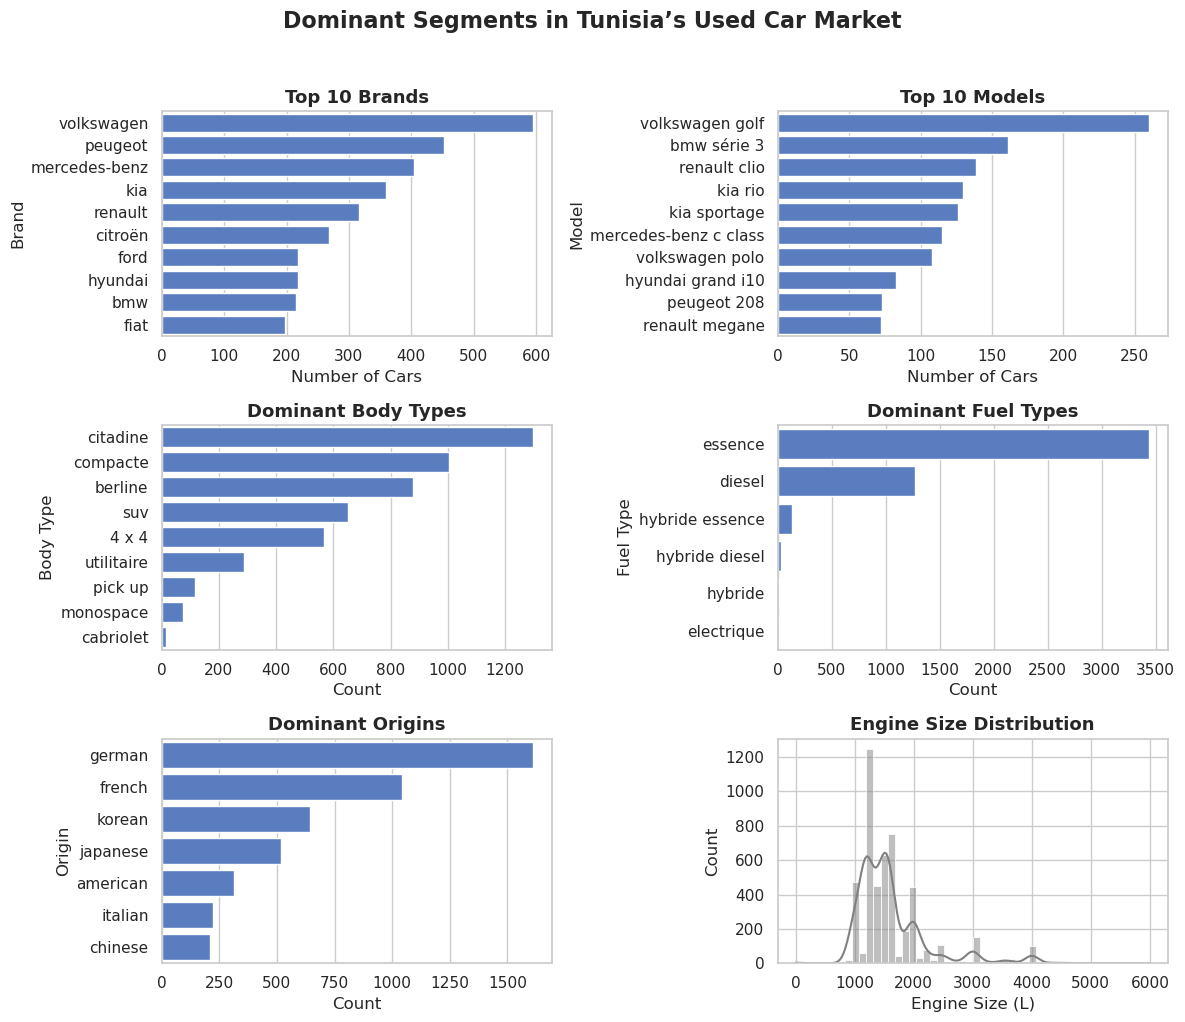

In [ ]:
df_market = df_base.copy()

fig, axes = plt.subplots(3, 2, figsize=(13, 10))
fig.suptitle("Tunisia Used Car Market: Composition and Dominant Segments", fontsize=16, fontweight="bold", y=1.02)

top_brands = df_market["brand"].value_counts().head(10)
sns.barplot(x=top_brands.values, y=top_brands.index, ax=axes[0, 0], color="#4C78A8")
axes[0, 0].set_title("Top 10 Brands by Listing Count", fontweight="bold")
axes[0, 0].set_xlabel("Listings (count)")
axes[0, 0].set_ylabel("Brand")
format_count_axis(axes[0, 0], "x")

df_market["brand_model"] = df_market["brand"] + " " + df_market["model"]
top_models = df_market["brand_model"].value_counts().head(10)
sns.barplot(x=top_models.values, y=top_models.index, ax=axes[0, 1], color="#72B7B2")
axes[0, 1].set_title("Top 10 Models by Listing Count", fontweight="bold")
axes[0, 1].set_xlabel("Listings (count)")
axes[0, 1].set_ylabel("Model")
format_count_axis(axes[0, 1], "x")

sns.countplot(
    y="body-type",
    data=df_market,
    order=df_market["body-type"].value_counts().index,
    ax=axes[1, 0],
    color="#54A24B",
)
axes[1, 0].set_title("Body-Type Distribution", fontweight="bold")
axes[1, 0].set_xlabel("Listings (count)")
axes[1, 0].set_ylabel("Body type")
format_count_axis(axes[1, 0], "x")

sns.countplot(
    y="fuel",
    data=df_market,
    order=df_market["fuel"].value_counts().index,
    ax=axes[1, 1],
    color="#E45756",
)
axes[1, 1].set_title("Fuel-Type Distribution", fontweight="bold")
axes[1, 1].set_xlabel("Listings (count)")
axes[1, 1].set_ylabel("Fuel type")
format_count_axis(axes[1, 1], "x")

sns.countplot(
    data=df_market,
    y="origin",
    order=df_market["origin"].value_counts().head(7).index,
    ax=axes[2, 0],
    color="#F58518",
)
axes[2, 0].set_title("Top Origins by Listing Count", fontweight="bold")
axes[2, 0].set_xlabel("Listings (count)")
axes[2, 0].set_ylabel("Origin")
format_count_axis(axes[2, 0], "x")

sns.histplot(df_market["engine-size"], bins=50, kde=True, color="gray", ax=axes[2, 1])
axes[2, 1].set_title("Engine Size Concentration", fontweight="bold")
axes[2, 1].set_xlabel("Engine size (cc)")
axes[2, 1].set_ylabel("Listings (count)")
format_count_axis(axes[2, 1], "both")

plt.tight_layout()
plt.show()

**How to read this chart:** Each panel shows frequency concentration for a key market dimension (brand, model, body type, fuel, origin, engine size).
**Why it matters:** Concentration indicates where liquidity is highest and where affordability constraints shape demand.

- The listing mix is concentrated in a small set of brands and models, led by Volkswagen and other high-frequency European marques.
- City and compact formats dominate model-level representation, consistent with cost-sensitive urban demand.
- Petrol vehicles and mid-small engines (around 1.2L to 1.6L) remain the structural center of the market.
- Hybrid/electric categories are present but not yet central in listing volume.

 > 🔍 **Key Finding:** Tunisia's used-car market remains mass-market and utility-oriented, with concentration in practical vehicle formats.
 > 📌 **Interpretation:** Demand prioritizes resale liquidity, maintenance accessibility, and operating-cost control over premium features.
 > ✅ **Implication:** Inventory, financing, and dealership strategy should continue to target high-turnover compact and mid-range vehicle classes.

**Section takeaway:** Market composition supports a demand base centered on practical mobility rather than discretionary premium consumption.

---
## 🔁 5. Vehicle Lifecycle and Turnover Dynamics
*How age and mileage reveal replacement behavior under affordability pressure.*

**🎯 Why this matters**  
Lifecycle structure informs depreciation logic, financing horizons, and expected turnover velocity.

**🔎 What we analyze**
- Mileage concentration and tail behavior
- Vehicle age distribution and central age bands
- Registration-year context and cohort-linked pricing

**🧠 Key insight**  
The listing base indicates active mid-life circulation rather than predominantly end-of-life liquidation.

**✅ So what?**  
Pricing and risk models should capture age-mileage interaction and cohort dynamics, not isolated indicators.

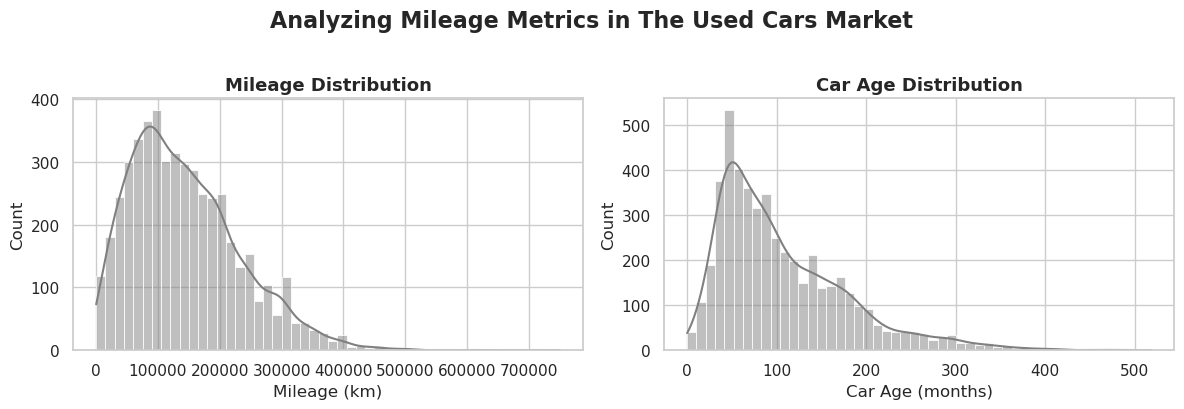

In [ ]:
df_lifecycle = df_base.copy()

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.5))
fig.suptitle("Turnover Signals from Mileage and Vehicle Age", fontsize=16, fontweight="bold", y=1.02)

sns.histplot(df_lifecycle["mileage"], bins=50, kde=True, color="gray", ax=axes[0])
axes[0].set_title("Mileage Distribution of Listings", fontweight="bold")
axes[0].set_xlabel("Mileage (km)")
axes[0].set_ylabel("Listings (count)")

sns.histplot(df_lifecycle["car-age"], bins=50, kde=True, color="gray", ax=axes[1])
axes[1].set_title("Vehicle Age Distribution", fontweight="bold")
axes[1].set_xlabel("Car age (months)")
axes[1].set_ylabel("Listings (count)")

plt.tight_layout()
plt.show()

**How to read this chart:** Both panels are right-skewed distributions that capture mileage concentration and vehicle-age concentration.

**Why it matters:** Turnover intensity affects financing needs, residual-value assumptions, and replacement behavior.

- Listings cluster in mid-mileage bands, while very high mileage appears less frequently.
- Vehicle-age concentration in lower-to-mid ranges is consistent with recurring resale cycles.

> 🔍 **Key Finding:** The market shows a relatively active turnover profile rather than a strictly long-hold ownership pattern.
> 📌 **Interpretation:** Sellers re-enter the market before extreme wear stages, especially in liquid segments.
> 🚀 **Implication:** Benchmarking should prioritize age-mileage interaction, not age in isolation.

**🧠 Key insight**  
Lifecycle behavior is a core market driver, not a peripheral metric.

**✅ So what?**  
Operational and pricing strategies should assume frequent circulation of practical, mid-age vehicles.

### 📅 5.1 Historical Registration and Pricing Context
*Linking vehicle cohorts to macro-period context and price levels.*

**🎯 Why this matters**  
Registration cohorts embed macro shocks and reveal how newer vs older vehicles are repriced in resale markets.

**🔎 What we analyze**
- Registration-year density and turning points around 2011 and post-2020
- Car-age concentration in months
- Average listed price by registration cohort

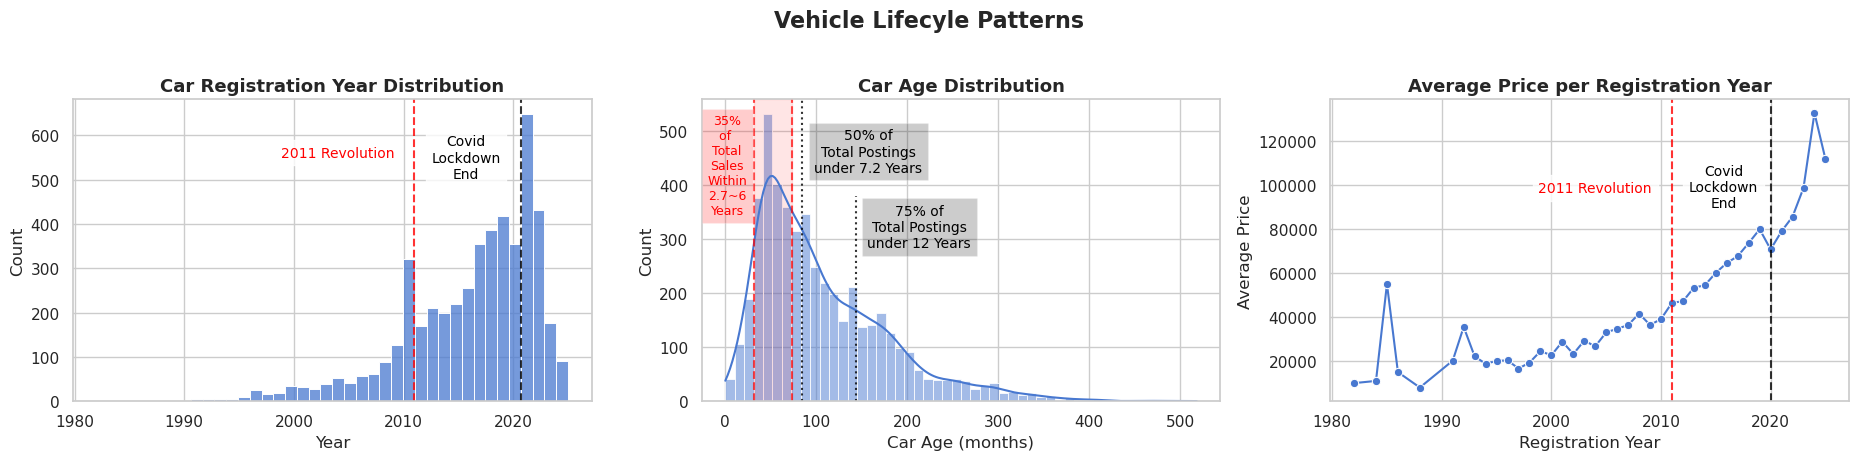

In [ ]:
df_lifecycle_2 = df_base.copy()

fig, axes = plt.subplots(1, 3, figsize=(19, 5))
fig.suptitle("Vehicle Lifecycle Patterns and Price Context", fontsize=16, fontweight="bold", y=1.03)

sns.histplot(df_lifecycle_2["year"], bins=40, ax=axes[0], color="#4C78A8")
axes[0].set_title("Registration Year Distribution", fontweight="bold")
axes[0].set_xlabel("Registration year")
axes[0].set_ylabel("Listings (count)")
axes[0].axvline(x=2011, linestyle="--", color="red", alpha=0.8)
axes[0].axvline(x=2020.7, linestyle="--", color="black", alpha=0.8)
format_count_axis(axes[0], "y")

sns.histplot(df_lifecycle_2["car-age"], kde=True, bins=50, ax=axes[1], color="#72B7B2")
axes[1].set_title("Car Age Distribution", fontweight="bold")
axes[1].set_xlabel("Car age (months)")
axes[1].set_ylabel("Listings (count)")
axes[1].axvline(x=84, linestyle=":", color="black", alpha=0.8, label="~7 years")
axes[1].axvline(x=144, linestyle=":", color="gray", alpha=0.8, label="~12 years")
axes[1].legend(loc="upper right")
format_count_axis(axes[1], "y")

avg_price_by_year = df_lifecycle_2.groupby("year", as_index=False)["price"].mean()
sns.lineplot(data=avg_price_by_year, x="year", y="price", marker="o", ax=axes[2], color="#E45756")
axes[2].set_title("Average Listed Price by Registration Year", fontweight="bold")
axes[2].set_xlabel("Registration year")
axes[2].set_ylabel("Average price (TND)")
axes[2].axvline(x=2011, linestyle="--", color="red", alpha=0.8)
axes[2].axvline(x=2020, linestyle="--", color="black", alpha=0.8)
format_tnd_axis(axes[2], "y")

plt.tight_layout()
plt.show()

**How to read this chart:** The first two panels show listing concentration across registration year and age, while the third links cohort year to average listed price.

**Why it matters:** This view connects turnover behavior with macro-period context and affordability dynamics.

- A large share of listings belongs to relatively recent registration cohorts.
- Age density remains concentrated below the oldest long-tail vehicle groups.
- Newer cohorts retain elevated nominal prices in the observed sample.

> 🔍 **Key Finding:** Lifecycle structure suggests active resale dynamics under rising nominal prices.
> 📌 **Interpretation:** Owners are rotating vehicles within practical ownership windows rather than holding until end-of-life.
> 🚀 **Implication:** Forecasting should emphasize sustained turnover in mid-age cohorts, especially in high-liquidity regions.

**🧠 Key insight**  
Cohort behavior and price levels move together in meaningful ways.

**✅ So what?**  
Lifecycle-aware pricing benchmarks should be standard in market monitoring.

---
## 🚚 6. Commercial vs Consumer Segment Analysis
*Comparing operational fleet logic with passenger-market behavior.*

**🎯 Why this matters**  
Commercial and consumer vehicles operate under different usage economics, mileage intensity, and replacement decisions.

**🔎 What we analyze**
- Share of commercial vs non-commercial listings
- Commercial segment price and mileage structure
- Regional concentration and brand profile within commercial listings

**🧠 Key insight**  
Commercial vehicles are fewer in count but structurally distinct in behavior.

**✅ So what?**  
Segment-specific pricing and risk assumptions are required; passenger-market rules do not transfer cleanly.

C:\Users\SBS\AppData\Local\Temp\ipykernel_5188\3671668350.py:42: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1,1].set_xticklabels(axes[1,1].get_xticklabels(), rotation=45)


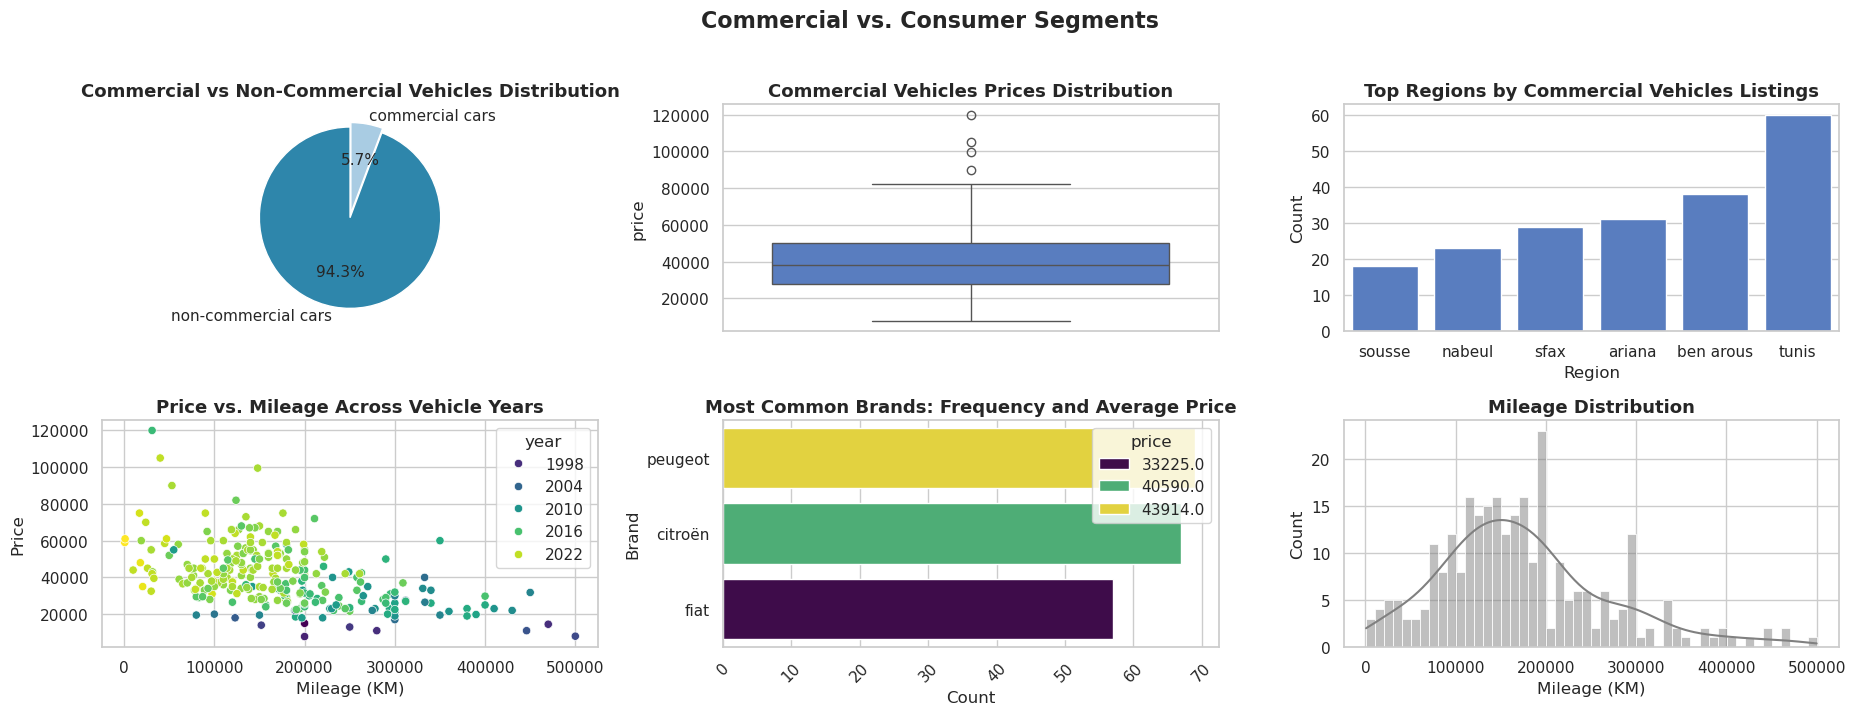

In [ ]:
df_segment = df_base.copy()

# Apply section-local data corrections to avoid mutating the shared baseline
df_segment = df_segment.drop(index=[2666, 1985], errors="ignore")
df_segment.loc[[1475, 2977, 2924, 2891, 2878], "body-type"] = "suv"

fig, axes = plt.subplots(2, 3, figsize=(19, 7.5))
fig.suptitle("Commercial vs Consumer Segment Structure", fontsize=16, fontweight="bold", y=1.02)

df_segment["category"] = np.where(
    df_segment["body-type"].eq("utilitaire"),
    "commercial cars",
    "non-commercial cars",
)
cat_counts = df_segment["category"].value_counts()
commercial_df = df_segment[df_segment["category"] == "commercial cars"].copy()

axes[0, 0].pie(
    cat_counts.values,
    labels=cat_counts.index,
    autopct="%1.1f%%",
    startangle=90,
    colors=["#2E86AB", "#A9CCE3"],
    explode=[0.05 if label == "commercial cars" else 0 for label in cat_counts.index],
    textprops={"fontsize": 10},
)
axes[0, 0].set_title("Market Share: Commercial vs Non-Commercial", fontweight="bold")

sns.boxplot(y=commercial_df["price"], ax=axes[0, 1], color="#72B7B2")
axes[0, 1].set_title("Commercial Vehicle Price Distribution", fontweight="bold")
axes[0, 1].set_ylabel("Price (TND)")
format_tnd_axis(axes[0, 1], "y")

bar_df = (
    commercial_df.groupby("location", as_index=False)["price"]
    .count()
    .sort_values("price")
    .tail(6)
    .rename(columns={"price": "count"})
)
sns.barplot(data=bar_df, x="location", y="count", ax=axes[0, 2], color="#54A24B")
axes[0, 2].set_title("Top Regions for Commercial Listings", fontweight="bold")
axes[0, 2].set_xlabel("Region")
axes[0, 2].set_ylabel("Listings (count)")
axes[0, 2].tick_params(axis="x", rotation=20)
format_count_axis(axes[0, 2], "y")

sns.scatterplot(
    data=commercial_df,
    x="mileage",
    y="price",
    hue="year",
    palette="viridis",
    ax=axes[1, 0],
    alpha=0.7,
    s=30,
    linewidth=0,
    legend=False,
)
axes[1, 0].set_title("Commercial Price vs Mileage by Year", fontweight="bold")
axes[1, 0].set_xlabel("Mileage (km)")
axes[1, 0].set_ylabel("Price (TND)")
format_count_axis(axes[1, 0], "x")
format_tnd_axis(axes[1, 0], "y")

top_commercial_brands = (
    commercial_df.groupby("brand", as_index=False)
    .agg(frequency=("brand", "count"), avg_price=("price", "mean"))
    .sort_values("frequency", ascending=False)
    .head(5)
)
sns.barplot(data=top_commercial_brands, x="frequency", y="brand", ax=axes[1, 1], color="#F58518")
axes[1, 1].set_title("Top Commercial Brands by Listing Count", fontweight="bold")
axes[1, 1].set_xlabel("Listings (count)")
axes[1, 1].set_ylabel("Brand")
format_count_axis(axes[1, 1], "x")

sns.histplot(commercial_df["mileage"], kde=True, bins=50, ax=axes[1, 2], color="gray")
axes[1, 2].set_title("Commercial Mileage Distribution", fontweight="bold")
axes[1, 2].set_xlabel("Mileage (km)")
axes[1, 2].set_ylabel("Listings (count)")
format_count_axis(axes[1, 2], "both")

plt.tight_layout()
plt.show()

**How to read this chart:** The grid combines segment share, pricing, geography, mileage, and brand concentration for commercial vehicles.

**Why it matters:** Commercial listings represent an operational market with different constraints than private passenger vehicles.

- Commercial vehicles represent a minority share, but with concentrated regional hubs.
- The segment shows broad mileage dispersion and mid-range price concentration with high-value outliers.
- Brand composition is concentrated in utility-oriented manufacturers.

> 🔍 **Key Finding:** Commercial vehicles form a specialized sub-market with distinct turnover and pricing behavior.
> 📌 **Interpretation:** Operational demand, fleet usage, and maintenance economics drive this segment more than lifestyle preferences.
> 🚀 **Implication:** Segment-specific underwriting and pricing logic should be treated as a standalone model family.

**🧠 Key insight**  
Commercial behavior is structurally different, not just a smaller version of the same market.

**✅ So what?**  
Separate dashboards and KPIs for commercial listings improve decision quality.

---
## 🌍 7. Geographic Segmentation and Regional Disparities
*Where pricing power and listing liquidity are geographically concentrated.*

**🎯 Why this matters**  
Spatial market differences reflect purchasing power distribution, economic activity concentration, and local market depth.

**🔎 What we analyze**
- Regional average-price distribution
- Concentration of premium/luxury listings by region
- Dominant body type by governorate and liquidity proxy patterns

**🧠 Key insight**  
Tunisia's used-car market exhibits a clear two-speed geography.

**✅ So what?**  
Regional strategy should be tiered, not nationally uniform.

This section maps structural differences between coastal/capital markets and interior regions using the same listing base.

**Regional snapshot indicators**

| Indicator | Observation |
|---|---|
| Highest listing concentration | Greater Tunis |
| Higher premium concentration | Capital and key coastal regions |
| Dominant body type in most regions | City-car/citadine profile |
| Interior vs coastal pattern | Lower average prices and thinner liquidity inland |

In [ ]:
df_geo = df_base.copy()
df_geo = df_geo.drop(columns=["Unnamed: 0"], errors="ignore")

In [ ]:
import geopandas as gpd

map_file_name = "geoBoundaries-TUN-ADM1.geojson"
search_roots = [Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent]

map_candidates = []
for root in search_roots:
    map_candidates.append(root / "data" / map_file_name)

# Keep order while removing duplicates
map_candidates = list(dict.fromkeys(map_candidates))
map_path = next((p for p in map_candidates if p.exists()), None)

if map_path is None:
    recursive_matches = []
    for root in search_roots:
        recursive_matches.extend(root.rglob(map_file_name))
    recursive_matches = list(dict.fromkeys(recursive_matches))
    map_path = recursive_matches[0] if recursive_matches else None

if map_path is None:
    checked = "\n".join(str(p.resolve()) for p in map_candidates)
    raise FileNotFoundError(
        "Could not locate Tunisia geojson boundary file. Checked:\n"
        f"{checked}\n\nAdd geoBoundaries-TUN-ADM1.geojson to one of the checked relative paths."
    )

tunisia_map = gpd.read_file(map_path)
map_names = tunisia_map["shapeName"].astype(str).unique().tolist()
df_names = df_geo["location"].astype(str).unique().tolist()

try:
    from rapidfuzz import process, fuzz

    def best_match(name):
        match, score, _ = process.extractOne(name, map_names, scorer=fuzz.WRatio)
        return match if score >= 70 else None

except Exception:
    from difflib import get_close_matches

    def best_match(name):
        matches = get_close_matches(name, map_names, n=1, cutoff=0.6)
        return matches[0] if matches else None

auto_map = {name: best_match(name) for name in df_names}
manual_map = {"le kef": "El Kef"}
final_map = {loc: (manual_map.get(loc) or auto_map.get(loc)) for loc in df_names}

still_unmatched = [k for k, v in final_map.items() if v is None]
print("Unmatched location names:", still_unmatched)

df_geo["map_region"] = df_geo["location"].map(final_map)

avg_price = df_geo.groupby("map_region", as_index=False)["price"].mean()
geo_merged = tunisia_map.merge(avg_price, left_on="shapeName", right_on="map_region", how="left")

luxury_brands = {
    "mercedes-benz", "bmw", "audi", "porsche", "land rover", "jaguar", "honda", "hummer",
    "dodge", "lexus", "infiniti", "volvo", "tesla", "mini", "ds", "cupra", "alfa romeo",
    "haval", "jeep", "byd",
}

df_geo["brand_norm"] = df_geo["brand"].astype(str).str.strip().str.lower()
df_geo["luxury"] = df_geo["brand_norm"].isin(luxury_brands).astype(int)

luxury_count = (
    df_geo.groupby("map_region", as_index=False)["luxury"]
    .sum()
    .rename(columns={"luxury": "luxury_count"})
)
geo_merged_2 = tunisia_map.merge(luxury_count, left_on="shapeName", right_on="map_region", how="left")

bodytype_mode = (
    df_geo.groupby("map_region")["body-type"]
    .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else None)
    .reset_index()
    .rename(columns={"body-type": "dominant_bodytype"})
)

Unmatched (need manual mapping): ['le kef']
Still unmatched (manually map these): []


C:\Users\SBS\AppData\Local\Temp\ipykernel_5188\630025870.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=bodytype_mode,x='dominant_bodytype',order=bodytype_mode['dominant_bodytype'].value_counts().index,palette='Blues_r', ax=axes[2])


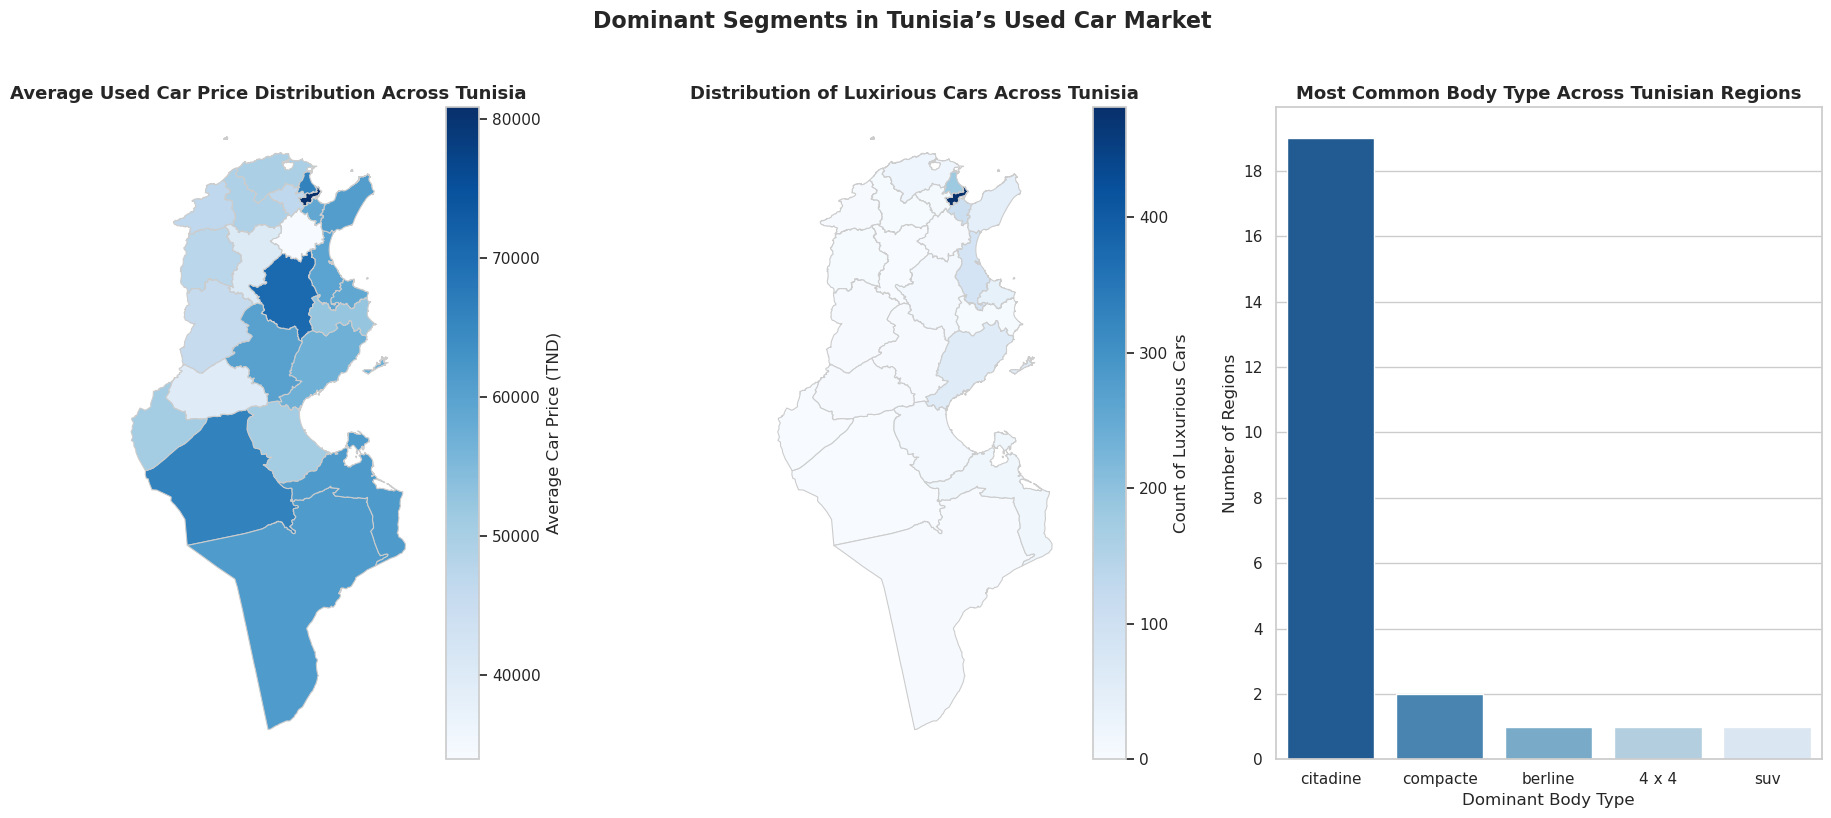

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(19, 8))
fig.suptitle("Regional Price, Premium Concentration, and Body-Type Dominance", fontsize=16, fontweight="bold", y=1.02)

geo_merged.plot(
    column="price",
    cmap="Blues",
    linewidth=0.8,
    edgecolor="0.8",
    legend=True,
    legend_kwds={"label": "Average listed price (TND)", "orientation": "vertical"},
    ax=axes[0],
)
axes[0].set_title("Average Used-Car Price by Region", fontweight="bold")
axes[0].axis("off")

geo_merged_2.plot(
    column="luxury_count",
    cmap="OrRd",
    linewidth=0.8,
    edgecolor="0.8",
    legend=True,
    legend_kwds={"label": "Luxury listing count", "orientation": "vertical"},
    ax=axes[1],
)
axes[1].set_title("Luxury Listing Concentration by Region", fontweight="bold")
axes[1].axis("off")

dominant_counts = bodytype_mode["dominant_bodytype"].value_counts().reset_index()
dominant_counts.columns = ["dominant_bodytype", "count"]
sns.barplot(data=dominant_counts, x="dominant_bodytype", y="count", color="#4C78A8", ax=axes[2])
axes[2].set_title("Most Common Dominant Body Type Across Regions", fontweight="bold")
axes[2].set_xlabel("Dominant body type")
axes[2].set_ylabel("Number of regions")
axes[2].tick_params(axis="x", rotation=25)
axes[2].yaxis.set_major_locator(mticker.MaxNLocator(integer=True))

plt.tight_layout()
plt.show()

**How to read this chart:** The first map shows average listed prices, the second map shows premium concentration, and the bar chart summarizes dominant body types by region.

**Why it matters:** Together, these panels show where pricing power and higher-end demand are concentrated.

> 🔍 **Key Finding:** Price and premium concentration are strongest in the capital and major coastal markets, while interior regions remain lower-priced.
> 📌 **Interpretation:** Regional liquidity and purchasing power are uneven, producing a structural coastal-interior divide.
> 🚀 **Implication:** Geographic strategy should differentiate inventory mix, financing products, and turnover expectations by region.

**🧠 Key insight**  
Geography is a first-order market variable, not just a descriptive split.

**✅ So what?**  
Regional segmentation should be explicit in any operational analytics stack.

Average listed prices form a clear regional gradient: higher values cluster in Greater Tunis and key coastal zones, while interior regions present lower averages. This pattern is consistent with stronger demand, liquidity, and income concentration in urban/coastal markets.

The map does not imply causality by itself, but it provides strong descriptive evidence that local economic intensity and market depth are associated with higher used-car valuations.

### 💎 7.1 Premium Concentration Lens
*Where premium demand is geographically anchored.*

**🎯 Why this matters**  
Premium concentration highlights where purchasing power and high-end liquidity converge.

**🔎 What we analyze**
- Regional concentration of luxury-oriented listings
- Alignment with urban/coastal economic intensity

Premium listings are heavily concentrated in Greater Tunis and major coastal cities such as Sfax and Sousse, while interior regions show lower counts.

> 🔍 **Key Finding:** Premium demand is geographically concentrated rather than nationally balanced.
> 📌 **Interpretation:** Income distribution, business density, and premium-service access likely reinforce this concentration.
> 🚀 **Implication:** Premium-focused inventory strategies should prioritize high-liquidity urban/coastal clusters.

**🧠 Key insight**  
The national market remains mass-market, with premium demand behaving as a regional niche layer.

**✅ So what?**  
Premium expansion decisions should be region-selective, not uniformly deployed.

### 🛞 7.2 Local Configuration Preferences
*Dominant body-type signals by region.*

**🎯 Why this matters**  
Body-type dominance is a practical proxy for local mobility needs and operating-cost priorities.

**🔎 What we analyze**
- Region-level dominant body type
- Interpretation of practical-use and terrain-linked preferences

City-car formats dominate most regions, indicating broad preference for lower running costs and easier resale.

> 🔍 **Key Finding:** Practical body configurations are structurally favored across governorates.
> 📌 **Interpretation:** Cost efficiency and liquidity likely outweigh discretionary configuration preferences in most regions.
> 🚀 **Implication:** Mainstream inventory planning should keep compact/city profiles as the default baseline.

**🧠 Key insight**  
Configuration preferences amplify the broader affordability-driven market structure.

**✅ So what?**  
Regional tuning matters, but practical formats should remain the core allocation strategy.

---
## 🧠 8. Consumer Preferences and Brand Positioning
*Decoding demand signals across origin, affordability, and fuel economics.*

**🎯 Why this matters**  
Preference structure determines long-run positioning of brands, technologies, and affordability tiers.

**🔎 What we analyze**
- Origin-based pricing and representation
- Affordability clustering and cumulative access profile
- Fuel economics and technical specification patterns

**🧠 Key insight**  
The market is path-dependent (legacy structure) yet gradually adaptive (new cohort signals).

**✅ So what?**  
Positioning strategy should balance current dominance with cohort-based transition indicators.

This section translates listing composition into preference signals relevant for buyers, dealers, and financing actors.

### 🌐 8.1 Brand Origin Positioning
*Comparing origin groups on representation, price, and cohort freshness.*

**🎯 Why this matters**  
Origin structure is a strong proxy for trust, positioning, and expected resale behavior.

**🔎 What we analyze**
- Average listed price by origin
- Listing prevalence by origin
- Dominant body type and average registration year by origin

In [ ]:
df_pref = df_base.copy()

C:\Users\SBS\AppData\Local\Temp\ipykernel_5188\2714859603.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=temp_1, x='price', y='origin', palette='Blues_d', ax=axes[0])
C:\Users\SBS\AppData\Local\Temp\ipykernel_5188\2714859603.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_brands, x='count', y='origin', ax=axes[1],palette='Blues_d')
C:\Users\SBS\AppData\Local\Temp\ipykernel_5188\2714859603.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=avg_year_by_brand, y='origin', x='year', palette='Blues_d', orient='h', 

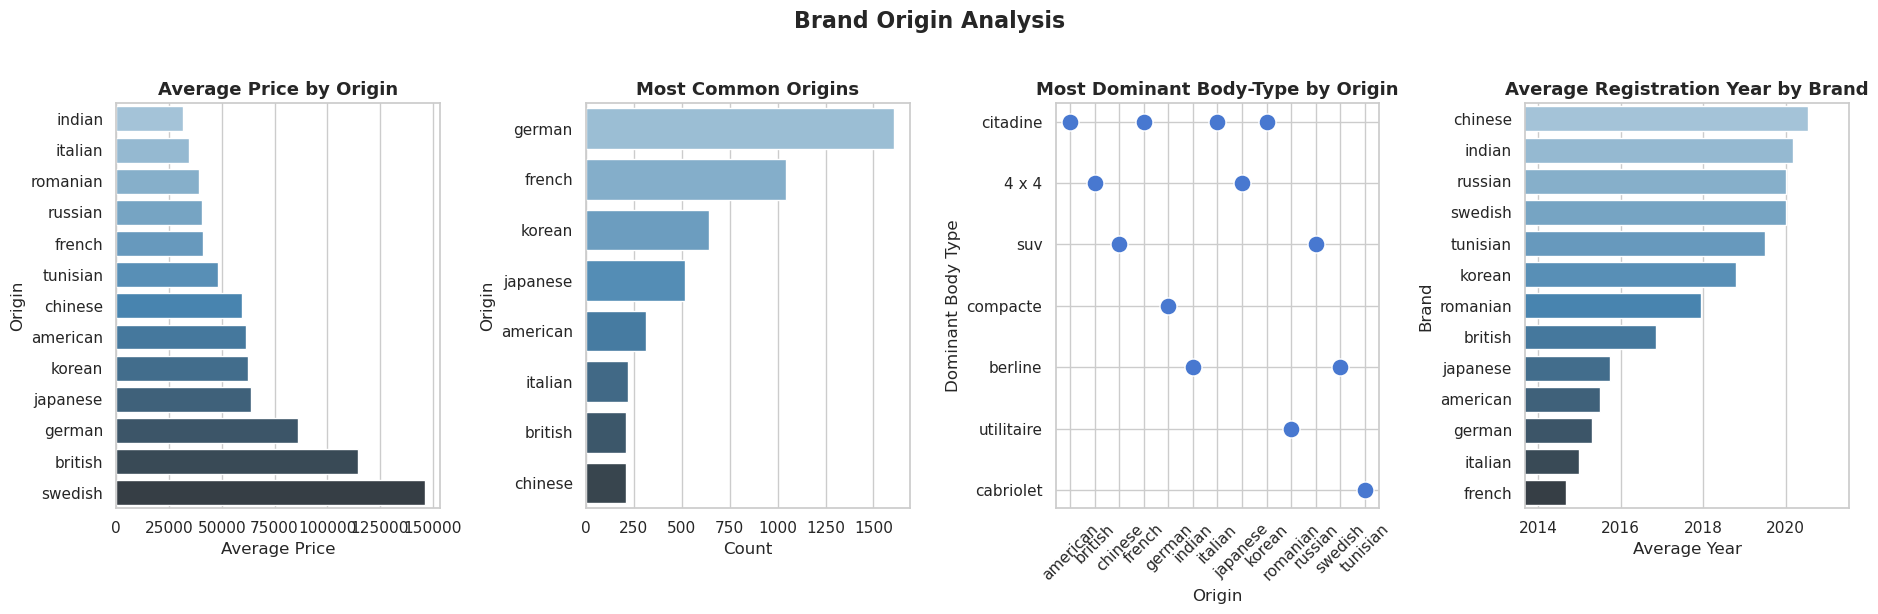

In [ ]:
origin_price = (
    df_pref.groupby("origin", as_index=False)
    .agg(avg_price=("price", "mean"), count=("price", "count"))
    .sort_values("avg_price")
)

top_origins = origin_price.sort_values("count", ascending=False).head(8)
avg_year_by_origin = df_pref.groupby("origin", as_index=False)["year"].mean().sort_values("year", ascending=False)
dominant_body = (
    df_pref.groupby("origin")["body-type"]
    .agg(lambda x: x.value_counts().index[0])
    .reset_index(name="dominant_body_type")
)

fig, axes = plt.subplots(1, 4, figsize=(19, 6))
fig.suptitle("Brand-Origin Positioning: Price, Presence, Configuration, and Cohort Age", fontsize=16, fontweight="bold", y=1.02)

sns.barplot(data=origin_price, x="avg_price", y="origin", color="#4C78A8", ax=axes[0])
axes[0].set_title("Average Price by Origin", fontweight="bold")
axes[0].set_xlabel("Average price (TND)")
axes[0].set_ylabel("Origin")

sns.barplot(data=top_origins, x="count", y="origin", color="#72B7B2", ax=axes[1])
axes[1].set_title("Most Common Origins", fontweight="bold")
axes[1].set_xlabel("Listings (count)")
axes[1].set_ylabel("Origin")

sns.scatterplot(data=dominant_body, x="origin", y="dominant_body_type", s=140, color="#E45756", ax=axes[2])
axes[2].set_title("Dominant Body Type by Origin", fontweight="bold")
axes[2].set_xlabel("Origin")
axes[2].set_ylabel("Dominant body type")
axes[2].tick_params(axis="x", rotation=30)

sns.barplot(data=avg_year_by_origin, y="origin", x="year", color="#F58518", ax=axes[3])
axes[3].set_title("Average Registration Year by Origin", fontweight="bold")
axes[3].set_xlabel("Average registration year")
axes[3].set_ylabel("Origin")

plt.tight_layout()
plt.show()

**How to read this chart:** Panels compare origin groups by price level, listing prevalence, dominant body type, and average registration-year profile.

**Why it matters:** Origin positioning reveals brand perception, affordability tiering, and likely composition shifts.

- European origins remain structurally dominant by listing share, with strong German and French representation.
- Price differences across origins reflect mixed premium and mass-market positioning.
- More recent average registration cohorts in selected origins suggest newer entry waves into resale circulation.

> 🔍 **Key Finding:** The market remains European-led, but cohort-age patterns suggest gradual diversification from newer-origin entrants.
> 📌 **Interpretation:** Consumer trust is path-dependent, yet newer vintages can shift perception over time.
> 🚀 **Implication:** Medium-term positioning should monitor cohort renewal, not only current share.

**🧠 Key insight**  
Legacy dominance and transition signals coexist in the same market.

**✅ So what?**  
Strategy should hedge for gradual origin diversification while respecting current liquidity realities.

### 💰 8.2 Price Clustering and Affordability
*Where market access is concentrated across price tiers.*

**🎯 Why this matters**  
Affordability distribution links listing behavior to household purchasing constraints.

**🔎 What we analyze**
- Listing distribution across price levels
- Cumulative access curve by price percentile
- Tiered concentration across accessible, mid-range, premium, and luxury buckets

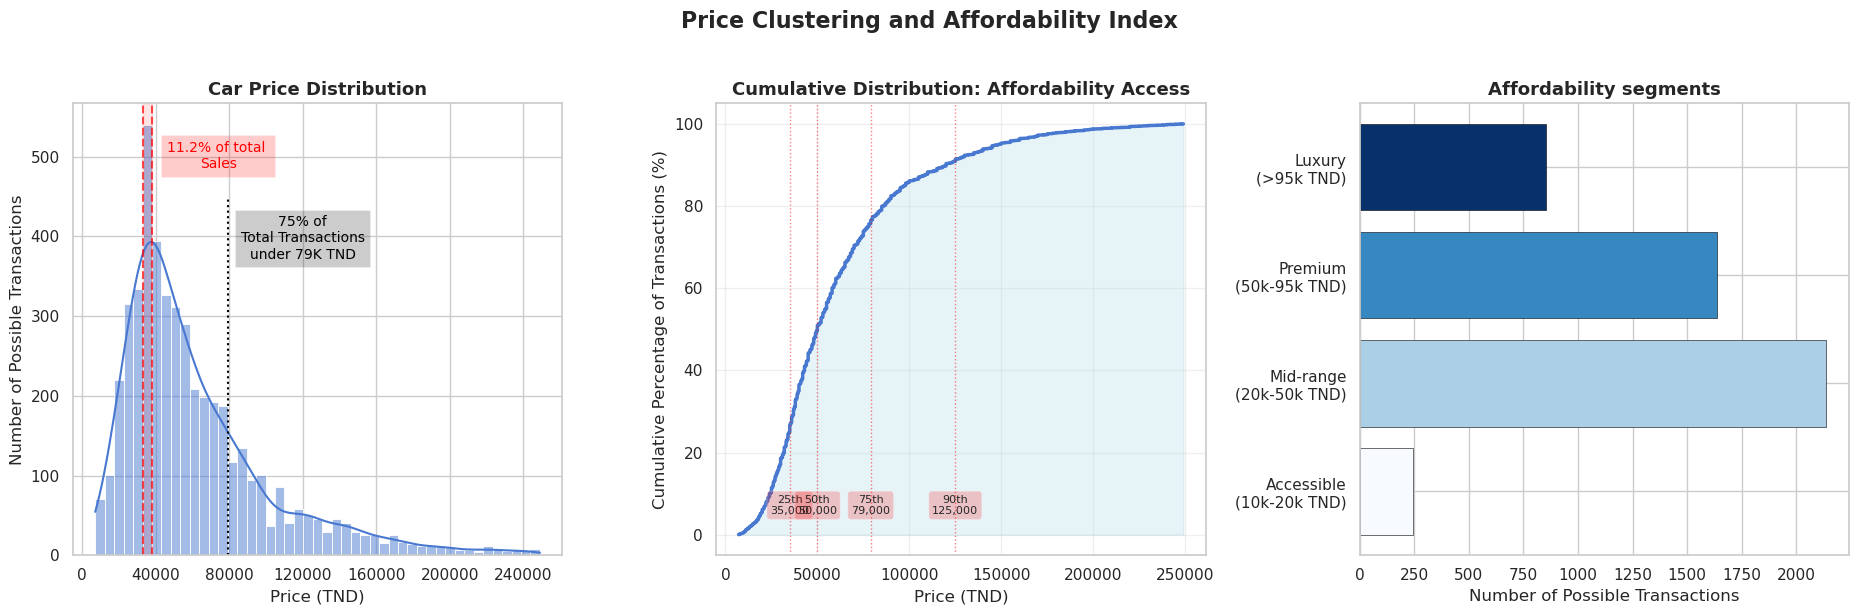

In [ ]:
df_afford = df_base.copy()

fig, axes = plt.subplots(1, 3, figsize=(19, 6))
fig.suptitle("Affordability Structure: Distribution, Access Curve, and Price Tiers", fontsize=16, fontweight="bold", y=1.02)

temp_afford = df_afford[df_afford["price"] < 250000].copy()

sns.histplot(data=temp_afford, x="price", ax=axes[0], bins=47, kde=True, color="#4C78A8")
axes[0].axvline(x=38000, linestyle="--", color="red", alpha=0.7)
axes[0].axvline(x=33000, linestyle="--", color="red", alpha=0.7)
axes[0].axvline(x=79500, linestyle=":", color="black", alpha=1.0)
axes[0].axvspan(33000, 38000, color="red", alpha=0.1)
axes[0].set_title("Price Distribution of Listings", fontweight="bold")
axes[0].set_xlabel("Price (TND)")
axes[0].set_ylabel("Listings (count)")
axes[0].xaxis.set_major_locator(mticker.MaxNLocator(7))
format_tnd_axis(axes[0], "x")
format_count_axis(axes[0], "y")

sorted_prices = np.sort(temp_afford["price"].dropna())
cumulative = np.arange(1, len(sorted_prices) + 1) / len(sorted_prices) * 100
axes[1].plot(sorted_prices, cumulative, linewidth=2.2, color="#54A24B")
axes[1].fill_between(sorted_prices, cumulative, alpha=0.25, color="#54A24B")
axes[1].set_xlabel("Price (TND)")
axes[1].set_ylabel("Cumulative listings (%)")
axes[1].set_title("Cumulative Access by Price", fontweight="bold")
axes[1].grid(alpha=0.3)
format_tnd_axis(axes[1], "x")

for p in [25, 50, 75, 90]:
    val = np.percentile(df_afford["price"].dropna(), p)
    axes[1].axvline(val, color="red", linestyle=":", alpha=0.5, linewidth=1)

segments = {
    "Accessible\n(10k-20k)": (10000, 20000),
    "Mid-range\n(20k-50k)": (20000, 50000),
    "Premium\n(50k-95k)": (50000, 95000),
    "Luxury\n(>95k)": (95000, df_afford["price"].max()),
}
segment_counts = {
    seg: len(df_afford[(df_afford["price"] >= lo) & (df_afford["price"] < hi)])
    for seg, (lo, hi) in segments.items()
}
axes[2].barh(list(segment_counts.keys()), list(segment_counts.values()), color=["#A0CBE8", "#4C78A8", "#F58518", "#E45756"])
axes[2].set_title("Affordability Tier Distribution", fontweight="bold")
axes[2].set_xlabel("Listings (count)")
axes[2].set_ylabel("Tier")
format_count_axis(axes[2], "x")

plt.tight_layout()
plt.show()

**How to read this chart:** The histogram shows price concentration, the cumulative curve shows percentile access, and the final panel compares affordability tiers.

**Why it matters:** Affordability structure links listing behavior directly to buyer budget constraints.

- Listings concentrate in lower-to-mid price bands, with tapering in higher tiers.
- The cumulative curve confirms most listings remain below upper mid-range thresholds.
- The lowest-price accessible tier exists but is narrower than mid-range and premium tiers.

> 🔍 **Key Finding:** The Tunisian used-car market is centered on the mid-range affordability segment.
> 📌 **Interpretation:** Buyers face constrained low-price access while premium inventory remains visible but less dominant by count.
> 🚀 **Implication:** Credit and product design should prioritize mid-range affordability stress.

**🧠 Key insight**  
Affordability pressure is the market's organizing force.

**✅ So what?**  
Financing and inventory strategy should optimize around mid-range demand depth.

### ⛽ 8.3 Fuel Type Economics and Technical Profile
*Understanding current fuel mix and transition readiness.*

**🎯 Why this matters**  
Fuel composition captures running-cost tradeoffs, policy effects, and adoption barriers.

**🔎 What we analyze**
- Fuel share by listing volume
- Price distribution by fuel type
- Engine-size, fiscal power, and cohort differences by fuel category

In [ ]:
df_fuel = df_base.copy()
df_fuel = df_fuel.drop(index=[3825], errors="ignore")

C:\Users\SBS\AppData\Local\Temp\ipykernel_5188\2247895113.py:77: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  temp = df.groupby('fuel').apply(lambda x: x.loc[x.groupby('model')['model'].transform('size').idxmax()]).reset_index(drop=True)
C:\Users\SBS\AppData\Local\Temp\ipykernel_5188\2247895113.py:80: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=temp, y='fuel', x=[1]*len(temp), ax=axes[1, 2], palette='Blues_r', orient='h')


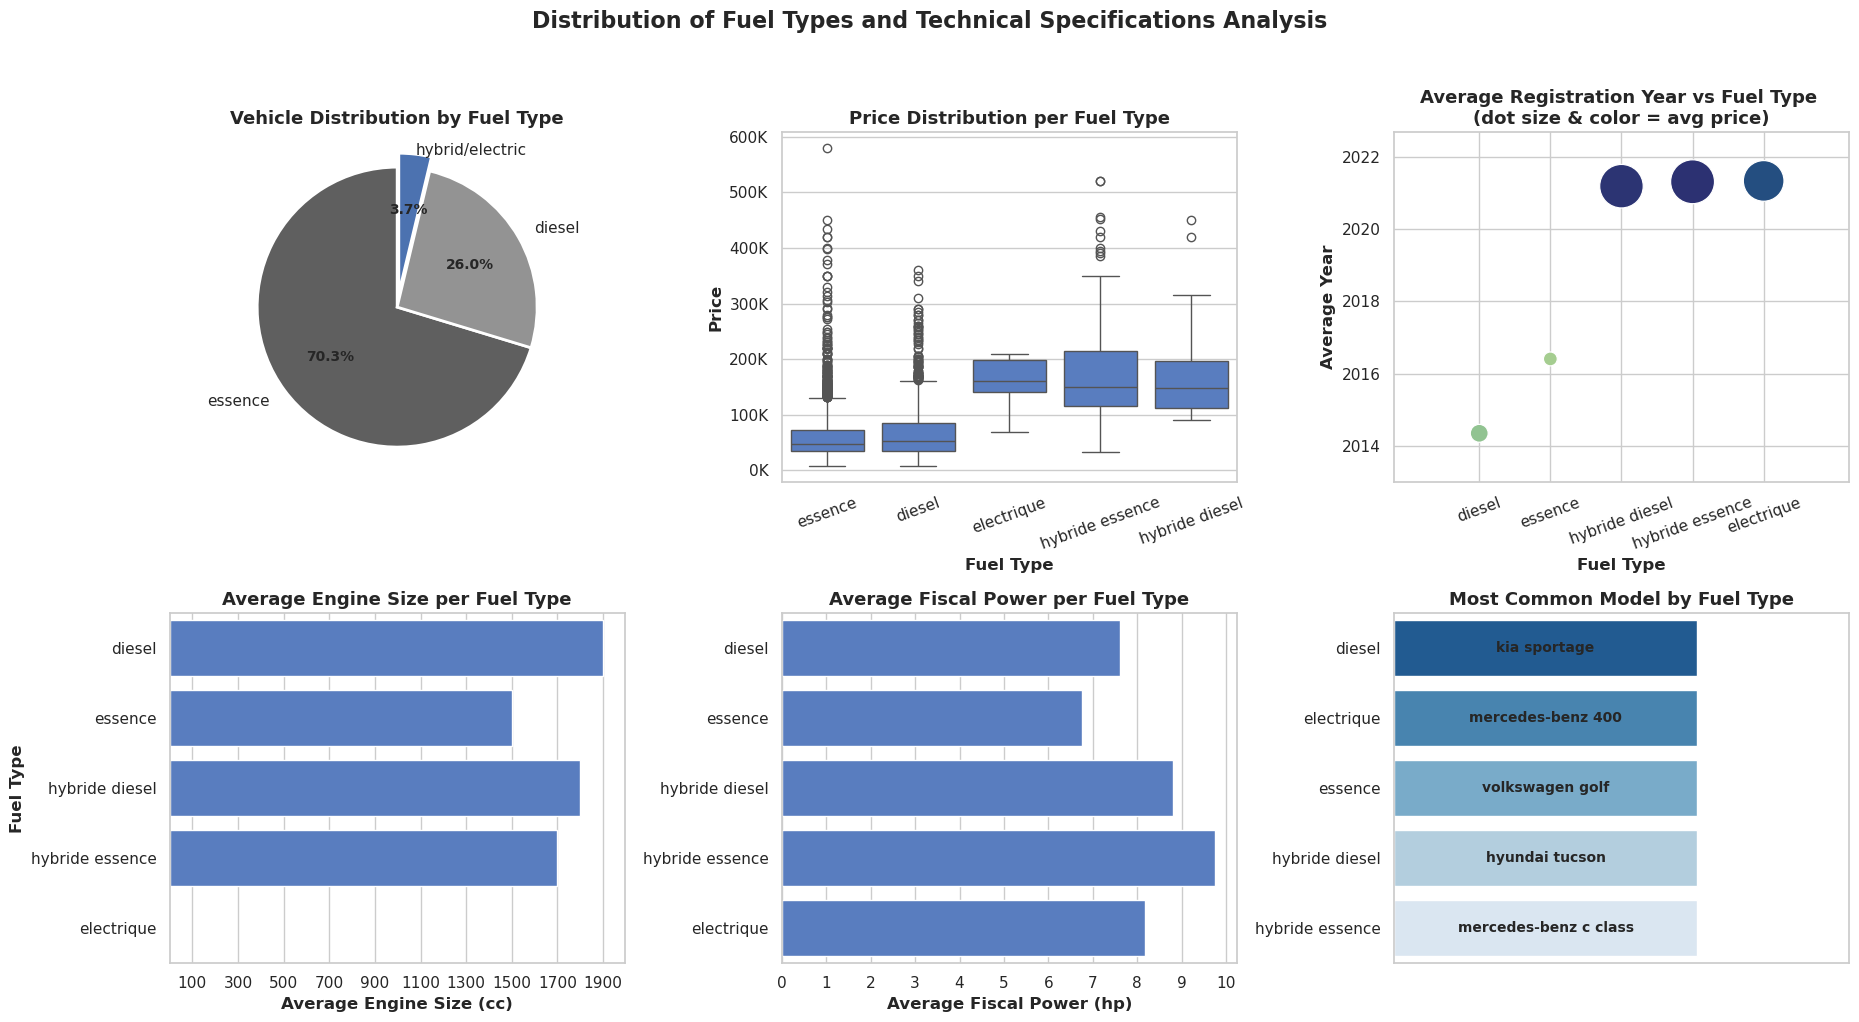

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(19, 10))
fig.suptitle("Fuel Mix, Pricing, and Technical Characteristics", fontsize=16, fontweight="bold", y=1.02)

fuel_counts = df_fuel.groupby("fuel", as_index=False)["price"].count().rename(columns={"price": "count"})
fuel_counts = fuel_counts.sort_values("count", ascending=False)

essence_count = fuel_counts.loc[fuel_counts["fuel"] == "essence", "count"].sum()
diesel_count = fuel_counts.loc[fuel_counts["fuel"] == "diesel", "count"].sum()
other_count = fuel_counts.loc[~fuel_counts["fuel"].isin(["essence", "diesel"]), "count"].sum()

axes[0, 0].pie(
    [essence_count, diesel_count, other_count],
    labels=["essence", "diesel", "hybrid/electric"],
    autopct="%1.1f%%",
    startangle=90,
    colors=["#B3CDE3", "#6497B1", "#005B96"],
    explode=(0, 0, 0.08),
)
axes[0, 0].set_title("Fuel Type Share", fontweight="bold")

df_fuel["fuel_clean"] = df_fuel["fuel"].replace({"hybride": "hybride essence"})
fuel_order = ["essence", "diesel", "electrique", "hybride essence", "hybride diesel"]
sns.boxplot(data=df_fuel, x="fuel_clean", y="price", order=fuel_order, ax=axes[0, 1], color="#72B7B2")
axes[0, 1].set_title("Price Distribution by Fuel Type", fontweight="bold")
axes[0, 1].set_xlabel("Fuel type")
axes[0, 1].set_ylabel("Price (TND)")
axes[0, 1].tick_params(axis="x", rotation=20)
format_tnd_axis(axes[0, 1], "y")

temp_engine = df_fuel.groupby("fuel_clean", as_index=False)["engine-size"].mean()
sns.barplot(data=temp_engine, y="fuel_clean", x="engine-size", order=fuel_order, ax=axes[1, 0], color="#4C78A8")
axes[1, 0].set_title("Average Engine Size by Fuel", fontweight="bold")
axes[1, 0].set_xlabel("Average engine size (cc)")
axes[1, 0].set_ylabel("Fuel type")
format_count_axis(axes[1, 0], "x")

temp_fp = df_fuel.groupby("fuel_clean", as_index=False)["fiscal-power"].mean()
sns.barplot(data=temp_fp, y="fuel_clean", x="fiscal-power", order=fuel_order, ax=axes[1, 1], color="#54A24B")
axes[1, 1].set_title("Average Fiscal Power by Fuel", fontweight="bold")
axes[1, 1].set_xlabel("Average fiscal power (hp)")
axes[1, 1].set_ylabel("")

temp_year_price = df_fuel.groupby("fuel_clean", as_index=False).agg(avg_year=("year", "mean"), avg_price=("price", "mean"))
sns.scatterplot(
    data=temp_year_price,
    x="fuel_clean",
    y="avg_year",
    size="avg_price",
    hue="avg_price",
    palette="crest",
    sizes=(120, 900),
    legend=False,
    ax=axes[0, 2],
)
axes[0, 2].set_title("Average Registration Year by Fuel\n(Size/Color = Average Price)", fontweight="bold")
axes[0, 2].set_xlabel("Fuel type")
axes[0, 2].set_ylabel("Average registration year")
axes[0, 2].tick_params(axis="x", rotation=20)

top_model_by_fuel = (
    df_fuel.groupby(["fuel_clean", "brand", "model"]).size().reset_index(name="count")
    .sort_values(["fuel_clean", "count"], ascending=[True, False])
    .drop_duplicates(subset=["fuel_clean"])
)
sns.barplot(data=top_model_by_fuel, y="fuel_clean", x="count", ax=axes[1, 2], color="#F58518")
axes[1, 2].set_title("Most Frequent Model by Fuel Type", fontweight="bold")
axes[1, 2].set_xlabel("Listings (count)")
axes[1, 2].set_ylabel("")
format_count_axis(axes[1, 2], "x")

for i, row in top_model_by_fuel.reset_index(drop=True).iterrows():
    axes[1, 2].text(
        row["count"] + 0.2,
        i,
        f"{row['brand']} {row['model']}",
        va="center",
        fontsize=9,
    )

plt.tight_layout()
plt.show()

**How to read this chart:** The panels compare fuel share, price distribution, technical attributes, cohort recency, and representative models.

**Why it matters:** Fuel structure links consumer cost constraints with policy/tax effects and technology adoption.

- Petrol dominates listings, with diesel second and hybrid/electric still relatively limited by volume.
- Hybrid/electric categories show higher average-price profiles in the observed sample.
- Technical profiles differ by fuel type, reflecting segmentation by use case and taxation context.

> 🔍 **Key Finding:** Fuel composition remains conventional, while lower-volume alternative fuels are concentrated in higher-price cohorts.
> 📌 **Interpretation:** Adoption exists but remains uneven due to affordability, infrastructure, and policy structure.
> 🚀 **Implication:** Transition planning should focus on gradual market adaptation, not immediate broad substitution.

**🧠 Key insight**  
Cost practicality remains the dominant market logic, even as transition signals emerge.

**✅ So what?**  
Technology-transition scenarios should be phased and affordability-aware.

---
## 📌 9. Consolidated Key Findings
*Ranked evidence-backed conclusions from the full analysis flow.*

**🎯 Why this matters**  
Decision-makers need a compact synthesis tied directly to chart evidence.

**🔎 What we analyze**
- Priority ranking of the strongest findings
- Traceability from claim to section evidence
- Actionability for market actors

**🧠 Key insight**  
The market is resilient but constrained: practical demand dominates while transition signals remain gradual.

**✅ So what?**  
Execution should prioritize affordability-aware, region-aware operating strategies.

### 🏁 Ranked Findings with Evidence Anchors

1. **🧭 Practical segment concentration is the market backbone.**  
Evidence: Section 4 composition panels (brand/model/body-type/fuel concentration).  
Implication: Inventory and pricing strategy should prioritize liquid compact and mid-range formats.

2. **💰 Affordability is structurally centered in mid-range tiers.**  
Evidence: Section 8.2 price distribution, cumulative access curve, and tier counts.  
Implication: Financing design should target mid-range affordability stress rather than premium-led assumptions.

3. **🌍 Regional disparities are structural, not marginal.**  
Evidence: Section 7 regional average-price and premium concentration maps.  
Implication: Region-differentiated stock mix, pricing, and risk frameworks are required.

4. **🚚 Commercial vehicles follow distinct economics.**  
Evidence: Section 6 commercial segment share, mileage-price behavior, and regional hubs.  
Implication: Fleet-oriented listings need separate forecasting and underwriting logic.

5. **⚡ Fuel transition is visible but still early-stage.**  
Evidence: Section 8.3 fuel share and fuel-specific price/cohort panels.  
Implication: Transition planning should assume gradual adoption under affordability and infrastructure constraints.

6. **🔁 Lifecycle patterns indicate active resale circulation.**  
Evidence: Section 5 age, mileage, registration-year, and cohort-price diagnostics.  
Implication: Depreciation and turnover models should emphasize mid-age market circulation windows.

---
## 💼 10. Business and Economic Implications
*Translating data evidence into operating and strategy implications.*

**🎯 Why this matters**  
Market concentration and affordability pressure directly influence pricing, risk, and growth decisions.

**🔎 What we analyze**
- Regional listing density as a liquidity indicator
- Concentration patterns aligned with economic centers
- Practical implications for dealers, lenders, and market operators

**🧠 Key insight**  
Economic geography and affordability structure jointly shape market performance.

**✅ So what?**  
Winning strategies require region-tiered deployment and segment-specific financial design.

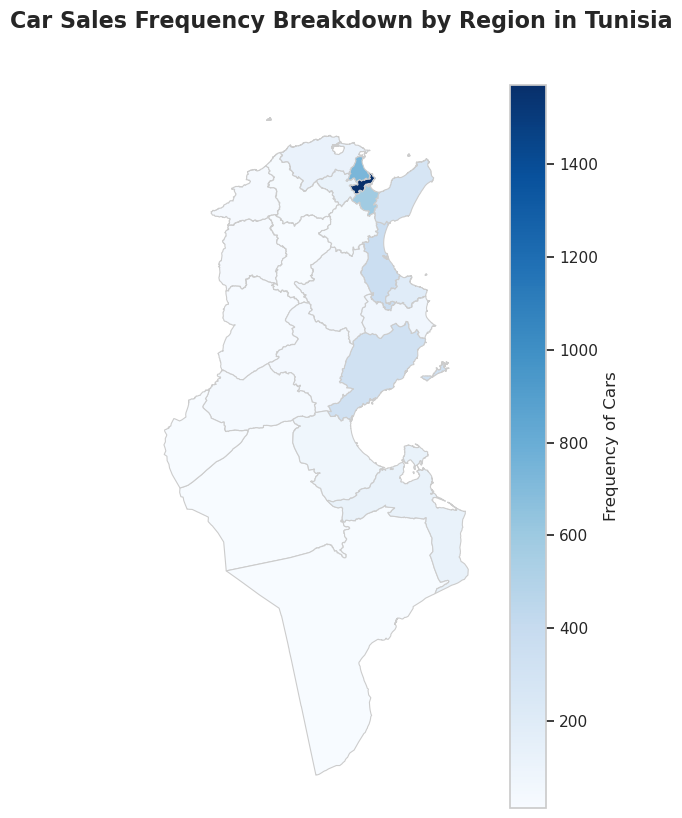

In [ ]:
frequency = df_geo.groupby("map_region", as_index=False)["price"].count()
geo_merged_last = tunisia_map.merge(frequency, left_on="shapeName", right_on="map_region", how="left")

fig, ax = plt.subplots(figsize=(6.5, 8))
geo_merged_last.plot(
    column="price",
    cmap="Blues",
    linewidth=0.8,
    edgecolor="0.8",
    legend=True,
    legend_kwds={"label": "Listing frequency (count)", "orientation": "vertical"},
    ax=ax,
)
fig.suptitle("Regional Listing Density in Tunisia", fontsize=16, fontweight="bold", y=1.02)
ax.axis("off")
fig.tight_layout()
plt.show()

**How to read this chart:** Darker regions indicate higher listing concentration, used here as a transaction-intensity proxy.

**Why it matters:** Concentration patterns indicate where liquidity and turnover are strongest.

- Greater Tunis appears as the primary concentration hub.
- Major coastal regions form the secondary liquidity corridor.
- Lower-density interior zones indicate thinner markets and lower transaction intensity.

> 🔍 **Key Finding:** Used-car activity is geographically concentrated in high-density economic centers.
> 📌 **Interpretation:** Listing concentration aligns with urbanization and regional economic intensity.
> 🚀 **Implication:** Commercial strategy should be region-tiered, with distinct inventory, pricing, and acquisition models.

**🧠 Key insight**  
Economic geography is a first-order determinant of listing liquidity.

**✅ So what?**  
Market operations should allocate resources by region tier, not with a uniform national playbook.

---
## ⚠️ 11. Limitations
*What this notebook does not claim, and why that matters for interpretation.*

**🎯 Why this matters**  
Transparent constraints preserve credibility and prevent over-interpretation.

**🔎 What we analyze**
- Coverage limits of platform-based listing data
- Descriptive scope versus causal inference
- Residual noise from metadata quality and category assignments

- The dataset reflects observed listings, not finalized transaction prices.
- Coverage is strong for major platforms but not exhaustive for offline or informal channels.
- Some category assignments depend on listing metadata and may include residual classification noise.
- Results are descriptive for the observed period and should not be interpreted as causal estimates.

**🧠 Key insight**  
The findings are robust for descriptive market intelligence within the observed sample.

**✅ So what?**  
Use this notebook as a high-quality decision support baseline, not a causal policy model.

---
## 🔭 12. Next Steps
*How to evolve this analysis into a continuous market intelligence product.*

**🎯 Why this matters**  
A roadmap turns this report from a snapshot into an operational analytics capability.

**🔎 What we analyze**
- Short-term analytical upgrades
- Medium-term modeling extensions
- Reporting automation opportunities

1. Extend the window to quarterly tracking for seasonality and trend stability checks.
2. Add confidence intervals or bootstrap uncertainty bands for key descriptive metrics.
3. Build segmented forecasting baselines for price and turnover by region and body type.
4. Integrate macro overlays (inflation, wage signals, and import policy changes).
5. Package core charts into a repeatable reporting pipeline for periodic updates.

**🧠 Key insight**  
The notebook already functions as a strong analytical baseline for scaled monitoring.

**✅ So what?**  
The next iteration should prioritize automation and uncertainty-aware reporting.

---
## 📎 13. Appendix
*Supplementary diagnostics kept for transparency without interrupting the main narrative.*

**🎯 Why this matters**  
Secondary diagnostics validate directionality while preserving story clarity in core sections.

**🔎 What we analyze**
- Additional correlation diagnostics
- Supplemental market structure and pricing views
- Supporting context for model-free exploratory interpretation

**🧠 Key insight**  
Appendix outputs should reinforce, not redefine, primary conclusions.

**✅ So what?**  
Core decisions should rely on Sections 4 to 10, with appendix charts used as corroborating evidence.

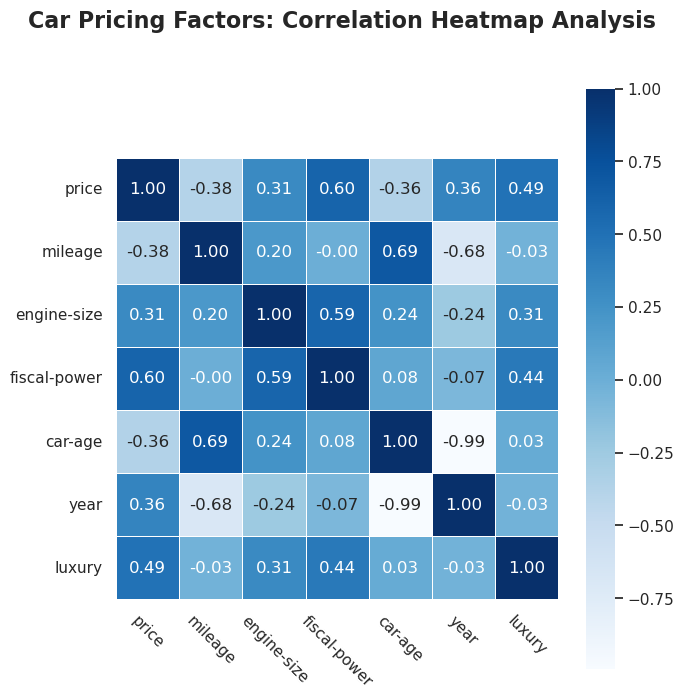

In [ ]:
df_appendix = df_base.copy()
fig = plt.figure(figsize=(7, 7))
correlation_matrix = df_appendix.corr(numeric_only=True)

sns.heatmap(
    correlation_matrix,
    cmap="Blues",
    annot=True,
    fmt=".2f",
    square=True,
    linewidths=0.5,
    cbar=True,
 )

fig.suptitle("Appendix: Correlation Matrix of Numerical Variables", fontsize=15, fontweight="bold", y=1.02)
plt.xticks(rotation=35, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

**How to read this chart:** Correlation coefficients summarize linear association strength between numeric variables.
**Why it matters:** This is a diagnostic view of co-movement, not a causal model.

The matrix confirms expected directional patterns (for example, positive association between fiscal power and price, and negative association between mileage and price).

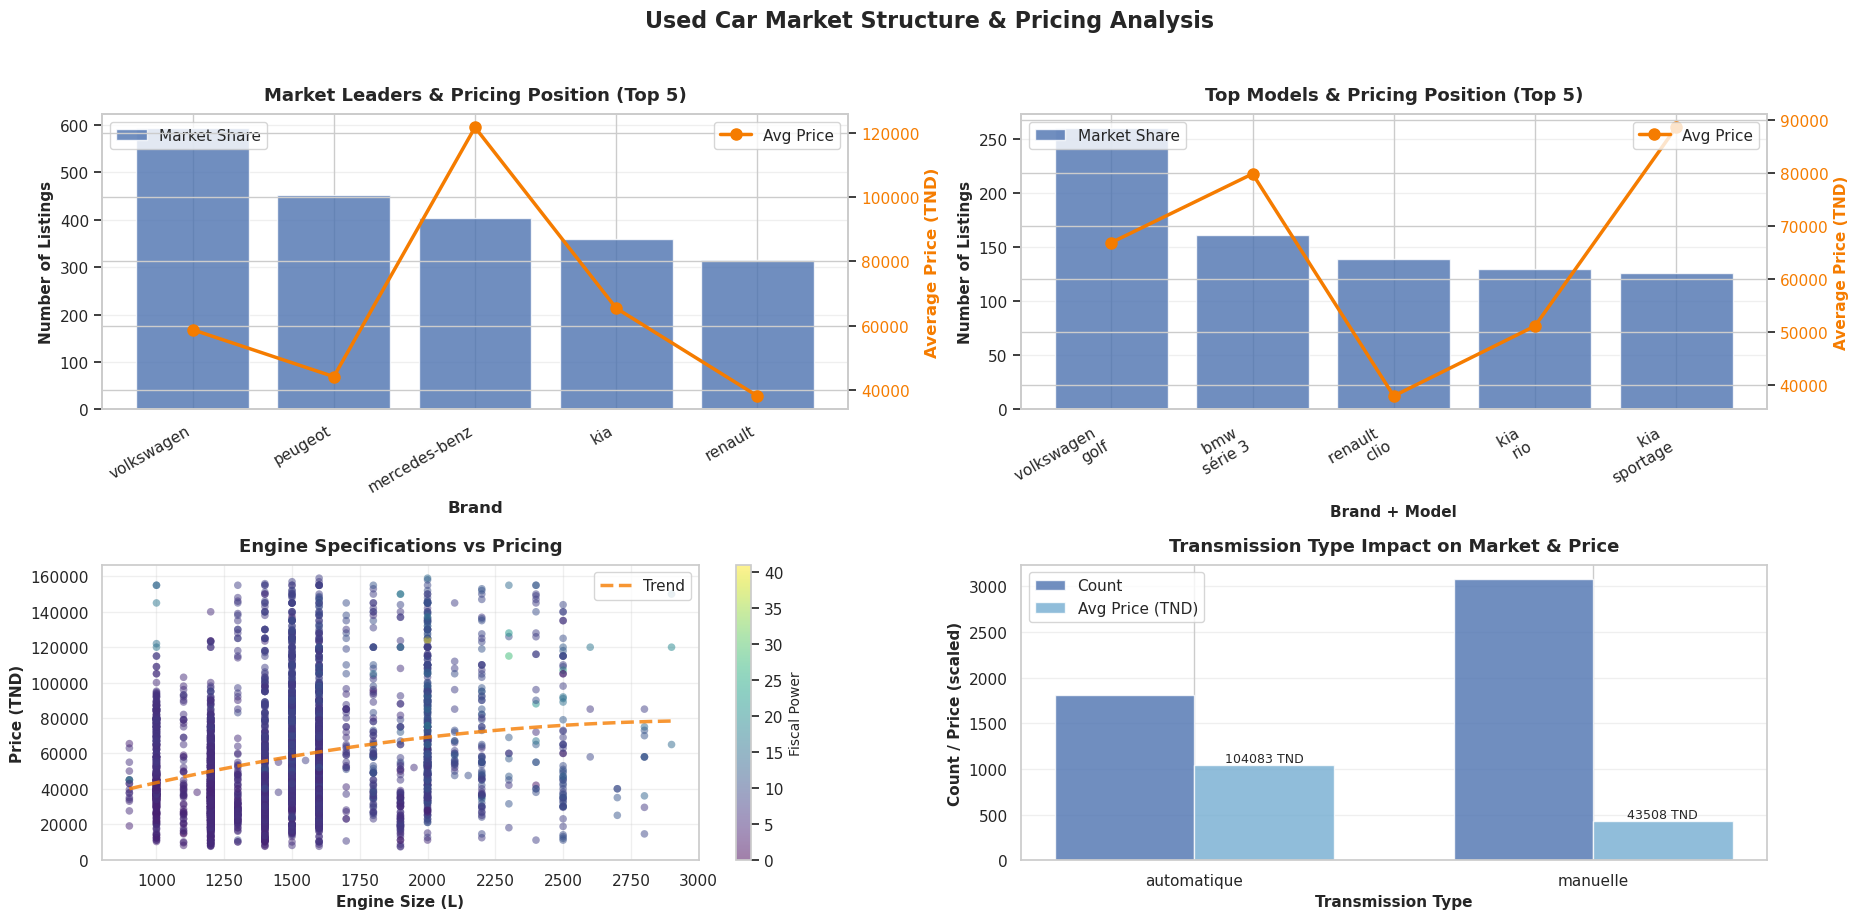

In [ ]:
df_appendix_2 = df_base.copy()

fig, axes = plt.subplots(2, 2, figsize=(19, 9))
fig.suptitle("Appendix: Supplemental Market Structure and Pricing Diagnostics", fontsize=16, fontweight="bold", y=1.02)

ax1 = axes[0, 0]
brand_stats = df_appendix_2.groupby("brand").agg(avg_price=("price", "mean"), count=("price", "count")).reset_index()
brand_stats = brand_stats.nlargest(5, "count")
ax1.bar(range(len(brand_stats)), brand_stats["count"], color="#4C78A8", alpha=0.85, label="Market share")
ax1.set_xticks(range(len(brand_stats)))
ax1.set_xticklabels(brand_stats["brand"], rotation=25, ha="right")
ax1.set_ylabel("Listings (count)")
ax1.set_xlabel("Brand")

ax1_twin = ax1.twinx()
ax1_twin.plot(range(len(brand_stats)), brand_stats["avg_price"], color="#F58518", marker="o", linewidth=2.2, label="Average price")
ax1_twin.set_ylabel("Average price (TND)")
ax1.set_title("Top-5 Brands: Frequency vs Average Price", fontweight="bold")
ax1.grid(axis="y", alpha=0.3)

ax2 = axes[0, 1]
df_appendix_2["brand_model"] = df_appendix_2["brand"] + " \n" + df_appendix_2["model"]
model_stats = df_appendix_2.groupby("brand_model").agg(avg_price=("price", "mean"), count=("price", "count")).reset_index()
model_stats = model_stats.nlargest(5, "count")
ax2.bar(range(len(model_stats)), model_stats["count"], color="#72B7B2", alpha=0.85, label="Market share")
ax2.set_xticks(range(len(model_stats)))
ax2.set_xticklabels(model_stats["brand_model"], rotation=25, ha="right")
ax2.set_ylabel("Listings (count)")
ax2.set_xlabel("Brand + model")
ax2_twin = ax2.twinx()
ax2_twin.plot(range(len(model_stats)), model_stats["avg_price"], color="#E45756", marker="o", linewidth=2.2, label="Average price")
ax2_twin.set_ylabel("Average price (TND)")
ax2.set_title("Top-5 Models: Frequency vs Average Price", fontweight="bold")
ax2.grid(axis="y", alpha=0.3)

ax3 = axes[1, 0]
df_clean = df_appendix_2[
    (df_appendix_2["engine-size"] < df_appendix_2["engine-size"].quantile(0.95))
    & (df_appendix_2["engine-size"] >= 700)
    & (df_appendix_2["price"] < df_appendix_2["price"].quantile(0.95))
]
scatter = ax3.scatter(
    df_clean["engine-size"],
    df_clean["price"],
    alpha=0.5,
    s=25,
    c=df_clean["fiscal-power"],
    cmap="viridis",
    edgecolors="none",
)
x_vals = df_clean["engine-size"].dropna()
y_vals = df_clean.loc[x_vals.index, "price"]
z = np.polyfit(x_vals, y_vals, 2)
poly = np.poly1d(z)
x_trend = np.linspace(x_vals.min(), x_vals.max(), 120)
ax3.plot(x_trend, poly(x_trend), color="#F58518", linestyle="--", linewidth=2.3, label="Quadratic trend")
ax3.set_xlabel("Engine size (cc)")
ax3.set_ylabel("Price (TND)")
ax3.set_title("Engine Size vs Price (Trimmed Sample)", fontweight="bold")
plt.colorbar(scatter, ax=ax3, label="Fiscal power")
ax3.legend()
ax3.grid(alpha=0.3)

ax4 = axes[1, 1]
gear_stats = df_appendix_2.groupby("gear").agg(avg_price=("price", "mean"), count=("price", "count")).reset_index()
x_pos = np.arange(len(gear_stats))
width = 0.35
ax4.bar(x_pos - width / 2, gear_stats["count"], width, label="Count", color="#4C78A8", alpha=0.85)
ax4.bar(x_pos + width / 2, gear_stats["avg_price"] / 100, width, label="Avg price / 100", color="#A0CBE8", alpha=0.85)
ax4.set_xticks(x_pos)
ax4.set_xticklabels(gear_stats["gear"])
ax4.set_ylabel("Count and scaled price")
ax4.set_xlabel("Transmission")
ax4.set_title("Transmission Mix and Pricing", fontweight="bold")
ax4.legend()
ax4.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

**How to read this chart:** These are supplemental diagnostics linking frequency, pricing, engine profile, and transmission structure.
**Why it matters:** They provide additional context for claims already made in the core narrative.

The diagnostics are directionally consistent with the main report sections: practical segments dominate by count, pricing differs by positioning, and engine/transmission patterns align with affordability-driven preferences.

**Section takeaway:** Appendix diagnostics reinforce, rather than alter, the core conclusions presented in sections 4 to 10.